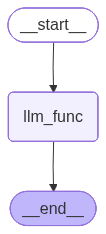

In [1]:
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages
from typing import Annotated
from typing_extensions import TypedDict
from IPython.display import Image,display


class State(TypedDict):
    messages : Annotated[list,add_messages]

llm = ChatOpenAI(model="gpt-4o-mini")

def llm_func(state:State):
    return {"messages":llm.invoke(state['messages'])}

builder = StateGraph(State)

builder.add_node('llm_func',llm_func)
builder.add_edge(START,'llm_func')
builder.add_edge('llm_func',END)

graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [2]:
graph.invoke({"messages":"Explain me about LLM"})

{'messages': [HumanMessage(content='Explain me about LLM', additional_kwargs={}, response_metadata={}, id='64307115-3788-4355-b4e9-1e163146d4f5'),
  AIMessage(content='LLM stands for "Large Language Model," which refers to a type of artificial intelligence that is trained to understand and generate human language. These models are built using deep learning techniques, particularly leveraging architectures like transformers, which have proven to be particularly effective for natural language processing tasks.\n\n### Key Features of LLMs:\n\n1. **Scale**: LLMs are characterized by their large number of parameters, often ranging from hundreds of millions to hundreds of billions. This scale allows them to capture complex linguistic patterns and nuances in language.\n\n2. **Training Data**: LLMs are trained on vast datasets that contain a diverse range of text from sources like books, articles, websites, and more. This exposure helps them learn context, grammar, facts, and the relationships